In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("adult.csv")

In [3]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.sample(5)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
40628,38,Private,192930,HS-grad,9,Separated,Sales,Unmarried,White,Female,0,0,10,United-States,<=50K
45662,66,Private,178120,5th-6th,3,Divorced,Priv-house-serv,Not-in-family,Black,Female,0,0,15,United-States,<=50K
23514,21,Private,65225,Some-college,10,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,30,United-States,<=50K
40868,17,Private,321880,10th,6,Never-married,Other-service,Own-child,Black,Male,0,0,15,United-States,<=50K
32057,41,Self-emp-inc,73431,Bachelors,13,Widowed,Prof-specialty,Unmarried,White,Female,0,0,40,United-States,<=50K


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [6]:
df.drop(columns=['fnlwgt','marital-status','race','native-country'],inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   education        48842 non-null  object
 3   educational-num  48842 non-null  int64 
 4   occupation       48842 non-null  object
 5   relationship     48842 non-null  object
 6   gender           48842 non-null  object
 7   capital-gain     48842 non-null  int64 
 8   capital-loss     48842 non-null  int64 
 9   hours-per-week   48842 non-null  int64 
 10  income           48842 non-null  object
dtypes: int64(5), object(6)
memory usage: 4.1+ MB


In [8]:
print("Duplicate: ",df.duplicated().sum())

Duplicate:  9617


In [9]:
df = df.drop_duplicates()

In [10]:
print(df.isnull().sum())

age                0
workclass          0
education          0
educational-num    0
occupation         0
relationship       0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
income             0
dtype: int64


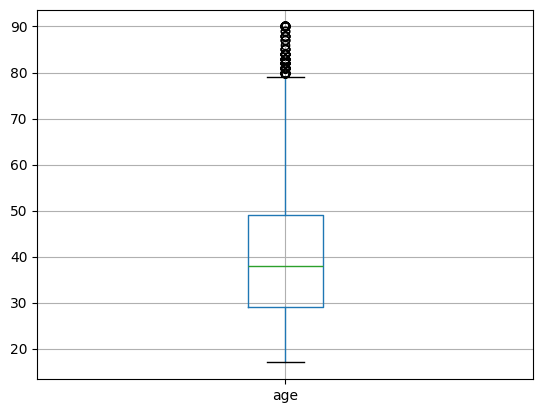

In [11]:
import matplotlib.pyplot as plt
df.boxplot(column='age')
plt.show()

In [12]:
Q1=df["age"].quantile(0.25)
Q3=df["age"].quantile(0.75)
IQR=Q3-Q1

df=df[~((df["age"]<(Q1-1.5*IQR))|
        (df["age"]>(Q3+1.5*IQR)))]
print("shape After remove outlier",df.shape)

shape After remove outlier (39042, 11)


In [13]:
# from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder

# le = LabelEncoder()
# df["age"] =le.fit_transform(df["age"])
# ohe_sex= OneHotEncoder(sparse_output=False,drop="first")
# encoded_sex=ohe_sex.fit_transform(df[["gender"]])
# encoded_sex_df = pd.DataFrame(encoded_sex,
#                               columns=ohe_sex.get_feature_names_out(["gender"]),
#                               index=df.index)
# df=pd.concat([df,encoded_sex_df],axis=1)
# df.drop(columns=["gender"],inplace=True)

# oe=OrdinalEncoder(categories=[["Some-college","Masters","HS-grad"]])
# df[["education"]] =oe.fit_transform(df[["education"]])

In [14]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

df = pd.read_csv("adult.csv")

# -----------------------------------------------
# 1. LabelEncoder — income (Target/Output column)
# -----------------------------------------------
# <=50K → 0,  >50K → 1
le = LabelEncoder()
df["income"] = le.fit_transform(df["income"])

# -----------------------------------------------
# 2. OneHotEncoder — gender (koi order nahi)
# -----------------------------------------------
# Female → 0,  Male → 1  (drop="first" se ek column hatao)
ohe_gender = OneHotEncoder(sparse_output=False, drop="first")
encoded_gender = ohe_gender.fit_transform(df[["gender"]])
encoded_gender_df = pd.DataFrame(encoded_gender,
                                  columns=ohe_gender.get_feature_names_out(["gender"]),
                                  index=df.index)
df = pd.concat([df, encoded_gender_df], axis=1)
df.drop(columns=["gender"], inplace=True)

# -----------------------------------------------
# 3. OneHotEncoder — workclass (9 categories, koi order nahi)
# -----------------------------------------------
ohe_work = OneHotEncoder(sparse_output=False, drop="first")
encoded_work = ohe_work.fit_transform(df[["workclass"]])
encoded_work_df = pd.DataFrame(encoded_work,
                                columns=ohe_work.get_feature_names_out(["workclass"]),
                                index=df.index)
df = pd.concat([df, encoded_work_df], axis=1)
df.drop(columns=["workclass"], inplace=True)

# -----------------------------------------------
# 4. OrdinalEncoder — education (order hai: Preschool < 1st-4th < ... < Doctorate)
# -----------------------------------------------
education_order = ['Preschool','1st-4th','5th-6th','7th-8th','9th',
                   '10th','11th','12th','HS-grad','Some-college',
                   'Assoc-voc','Assoc-acdm','Bachelors',
                   'Masters','Prof-school','Doctorate']

oe_edu = OrdinalEncoder(categories=[education_order])
df[["education"]] = oe_edu.fit_transform(df[["education"]])

# -----------------------------------------------
# 5. LabelEncoder — marital-status, occupation, relationship, race, native-country
# -----------------------------------------------
le_cols = ["marital-status", "occupation", "relationship", "race", "native-country"]
for col in le_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

print(df.head())
print(df.dtypes)

   age  fnlwgt  education  educational-num  marital-status  occupation  \
0   25  226802        6.0                7               4           7   
1   38   89814        8.0                9               2           5   
2   28  336951       11.0               12               2          11   
3   44  160323        9.0               10               2           7   
4   18  103497        9.0               10               4           0   

   relationship  race  capital-gain  capital-loss  ...  income  gender_Male  \
0             3     2             0             0  ...       0          1.0   
1             0     4             0             0  ...       0          1.0   
2             0     4             0             0  ...       1          1.0   
3             0     2          7688             0  ...       1          1.0   
4             3     4             0             0  ...       0          0.0   

   workclass_Federal-gov  workclass_Local-gov  workclass_Never-worked  \
0      